# NF-GWTC4

Learn the density of parameters in GWTC-4 data.

### Imports

In [16]:
import os
import h5py
import numpy as np
import pandas as pd
from scipy.special import logit, expit

import matplotlib.pyplot as plt
import corner

import jax
import jax.numpy as jnp
import optax
import equinox as eqx

# FlowJAX (new API)
from flowjax.flows import masked_autoregressive_flow
from flowjax.distributions import Normal

from pathlib import Path

import seaborn as sns
from tqdm import tqdm, trange

import utils as ut

# silence unnecessary warnings about some specific model not being available (shouldn't hurt performance according to ChatGPT)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import os
import socket
print(f"Hostname: {socket.gethostname()}")
print(f"CUDA_VISIBLE_DEVICES: {os.environ.get('CUDA_VISIBLE_DEVICES')}")
!nvidia-smi

Hostname: usm-cl-nv01.hpc.physik.uni-muenchen.de
CUDA_VISIBLE_DEVICES: 0
Tue Jan 27 22:43:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.195.03             Driver Version: 570.195.03     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 NVL                On  |   00000000:07:00.0 Off |                    0 |
| N/A   44C    P0             64W /  400W |       0MiB /  95830MiB |      0%      Default |
|                                         |                        

In [3]:
jax.devices()

[CudaDevice(id=0)]

### Load File

In [4]:
# fname = Path("/hildafs/home/jgassert/hildafs_phy220048p_symlink/share/GWTC-PESamples/posterior_samples/O4/GWTC-4_bbh_posterior_samples_seed1.h5")
# fname = Path("/project/ls-gruen/users/julius.gassert/data/samples-rpo4a_v2_20250503133839UTC-1366933504-23846400.hdf")
fname = Path("/project/ls-gruen/users/julius.gassert/data/GWTC-4_bbh_posterior_samples_seed1.h5")

col_names = ['a1', 'a2', 'chieff', 'dL', 'dec', 'm1det', 'm2det', 'ra', 'z']

f = h5py.File(fname, "r")
f.keys()

<KeysViewHDF5 ['a1', 'a2', 'chieff', 'dL', 'ddL_dz', 'dec', 'eventname', 'm1det', 'm2det', 'nsamp_original', 'ra', 'samples_type', 'tilt1', 'tilt2', 'z']>

In [5]:
data_dict = {}
for name in col_names:
    data_dict[name] = f[name]
    
data_df = pd.DataFrame(data_dict)
data_df

,a1,a2,chieff,dL,dec,m1det,m2det,ra,z
0,0.817295,0.235958,0.037938,744.780712,-0.347712,13.084350,8.864973,3.760685,0.151570
1,0.144075,0.099470,0.037893,1266.505480,-0.218457,12.015656,9.584306,2.213521,0.244240
2,0.488505,0.986123,0.153814,1052.335337,-0.358828,18.647186,6.429097,2.190627,0.207185
3,0.502167,0.791982,0.237423,1210.112600,-0.177346,20.772924,5.968823,2.313243,0.234602
4,0.309616,0.431722,-0.001070,1235.278947,-1.244381,13.921387,8.214377,2.848786,0.238913
...,...,...,...,...,...,...,...,...,...
62395,0.396275,0.340723,-0.008187,1291.614499,-0.671061,10.508656,10.233613,1.967213,0.248505
62396,0.545958,0.647109,0.082029,1586.290539,0.281023,14.407145,7.653825,5.684957,0.297459
62397,0.630492,0.296525,-0.026222,1879.250697,0.162250,10.510416,10.213382,5.494273,0.344341
62398,0.241268,0.796395,0.183323,1616.101450,0.626324,17.518980,6.476583,6.217886,0.302306


In [37]:
data = ut.Data(data_df, cols = ["m1det", "m2det", "dL", "chieff", "ra", "dec"])

### Prepare the data

FORWARD / INVERSE TRANSFORMS + WHITENING

In [38]:
# check that transform + inverse transform is identity
reverse_transform_data = data.inverse_transform(data.samples_transformed)
np.allclose(reverse_transform_data, data.samples, rtol=1e-6, atol=1e-6) # standard atol is slightly lower, but this is fine

True

In [39]:
# check that transform + whiten + inverse whiten + inverse transform is identity
x_white = data.whitened_data
x_rec = data.inverse_whiten_data(x_white)
np.allclose(x_rec, data.samples, rtol=1e-2, atol=1e-4)

False

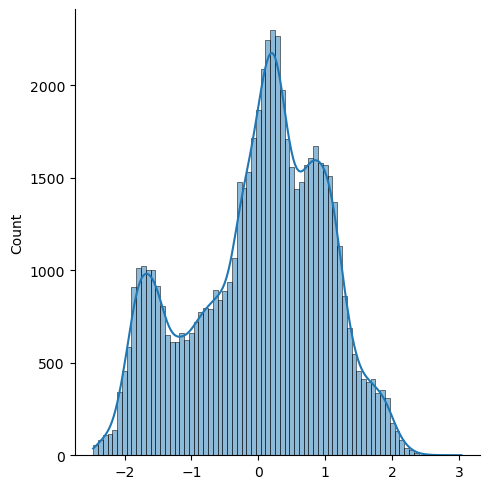

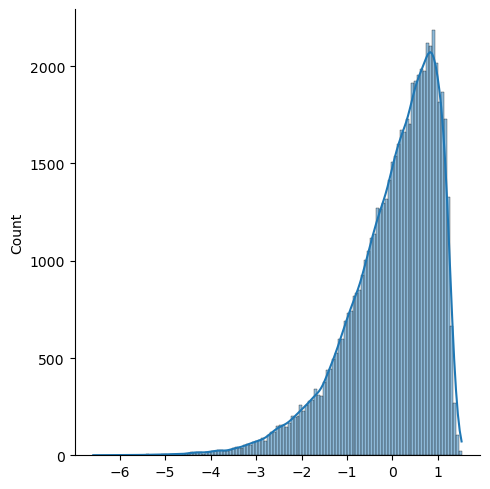

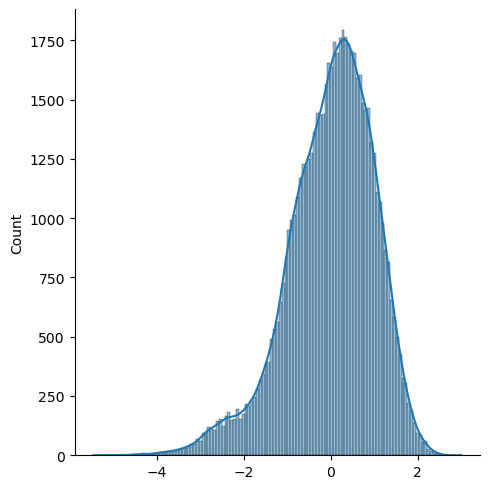

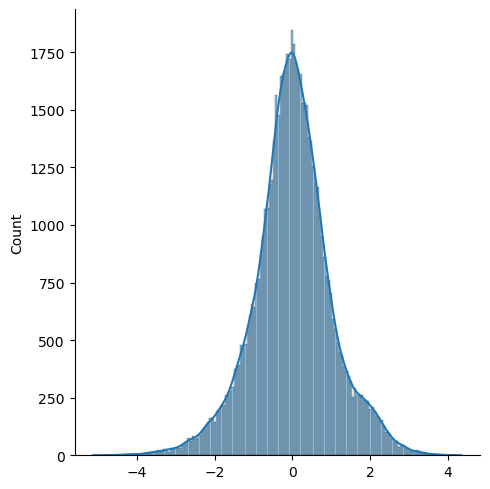

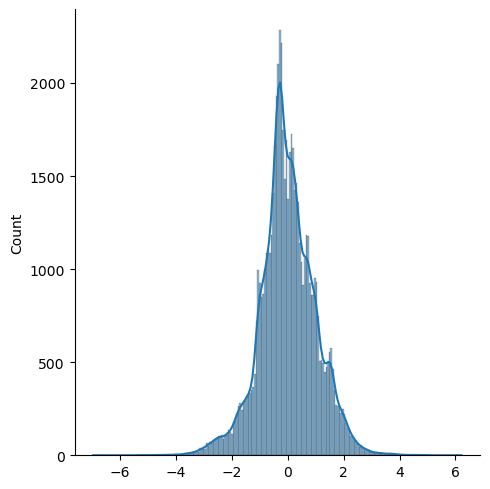

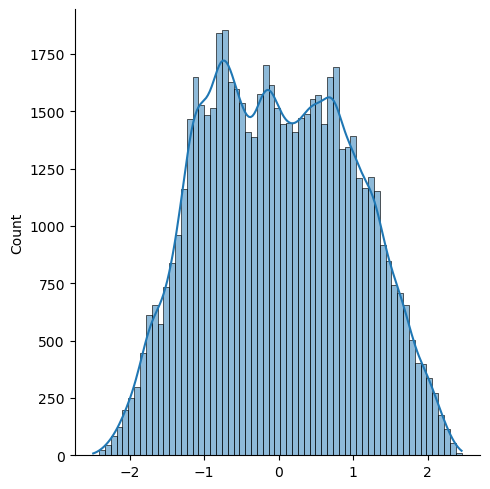

In [40]:
for i in range(data.whitened_data.shape[1]):

    sns.displot(np.array(data.whitened_data[:, i]), kde=True)
    plt.show()

### Build Flowjax MAF

In [41]:
key = jax.random.key(0)

base_dist = Normal(jnp.zeros(data.dim), jnp.ones(data.dim))

flow = masked_autoregressive_flow(
    key=key,
    base_dist=base_dist,
    flow_layers=14,
    nn_width=128,
    nn_depth=5,
)

### Training Loop

In [42]:
batch_size = 2048
n_epochs = 5000
optimizer = optax.adam(1e-3)

# Only trainable leaves (arrays)
opt_state = optimizer.init(eqx.filter(flow, eqx.is_array))

@eqx.filter_value_and_grad
def loss_fn(flow, x):
    return -jnp.mean(flow.log_prob(x))

@eqx.filter_jit
def train_step(flow, opt_state, x):
    loss, grads = loss_fn(flow, x)
    updates, opt_state = optimizer.update(grads, opt_state)
    flow = eqx.apply_updates(flow, updates)
    return flow, opt_state, loss

losses = []
N = len(data)

patience = 500

best_loss = np.inf
best_epoch = 0
best_flow = flow

epochs = trange(1, n_epochs + 1, desc="Training")

for epoch in epochs:
    perm = np.random.permutation(N)
    x_perm = data.whitened_data[perm]

    batch_losses = []
    for i in range(0, N, batch_size):
        batch = x_perm[i:i+batch_size]
        if batch.shape[0] < batch_size:
            continue
        flow, opt_state, loss = train_step(flow, opt_state, batch)
        batch_losses.append(float(loss))

    curr_loss = np.mean(batch_losses)
    losses.append(curr_loss)

    if curr_loss < best_loss:
        best_loss = curr_loss
        best_epoch = epoch
        best_flow = flow

    # Update tqdm bar
    epochs.set_postfix(
        curr=f"{curr_loss:.4f}",
        best=f"{best_loss:.4f}",
    )

    if epoch - best_epoch > patience:
        print(f"Early stopping at epoch {epoch}")
        break

flow = best_flow

Training:  69%|██████▊   | 3432/5000 [09:41<04:25,  5.90it/s, best=4.2667, curr=inf]   

Early stopping at epoch 3433


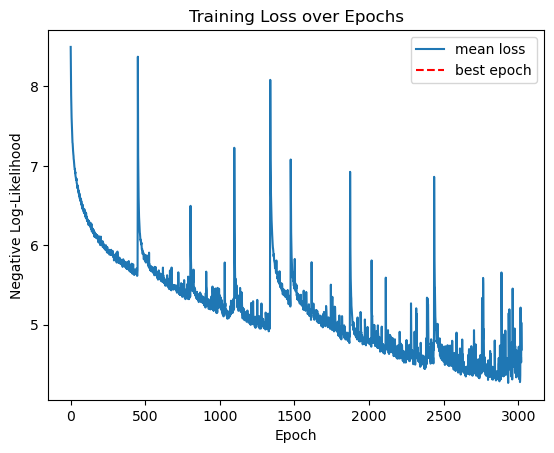

In [43]:
sns.lineplot(x=np.arange(1, len(losses) + 1), y=losses, label = "mean loss")
plt.vlines(x = best_epoch, ymin = min(losses), ymax = max(losses), color = "red", linestyle = "--", label = "best epoch")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Negative Log-Likelihood")
plt.title("Training Loss over Epochs")
plt.show()

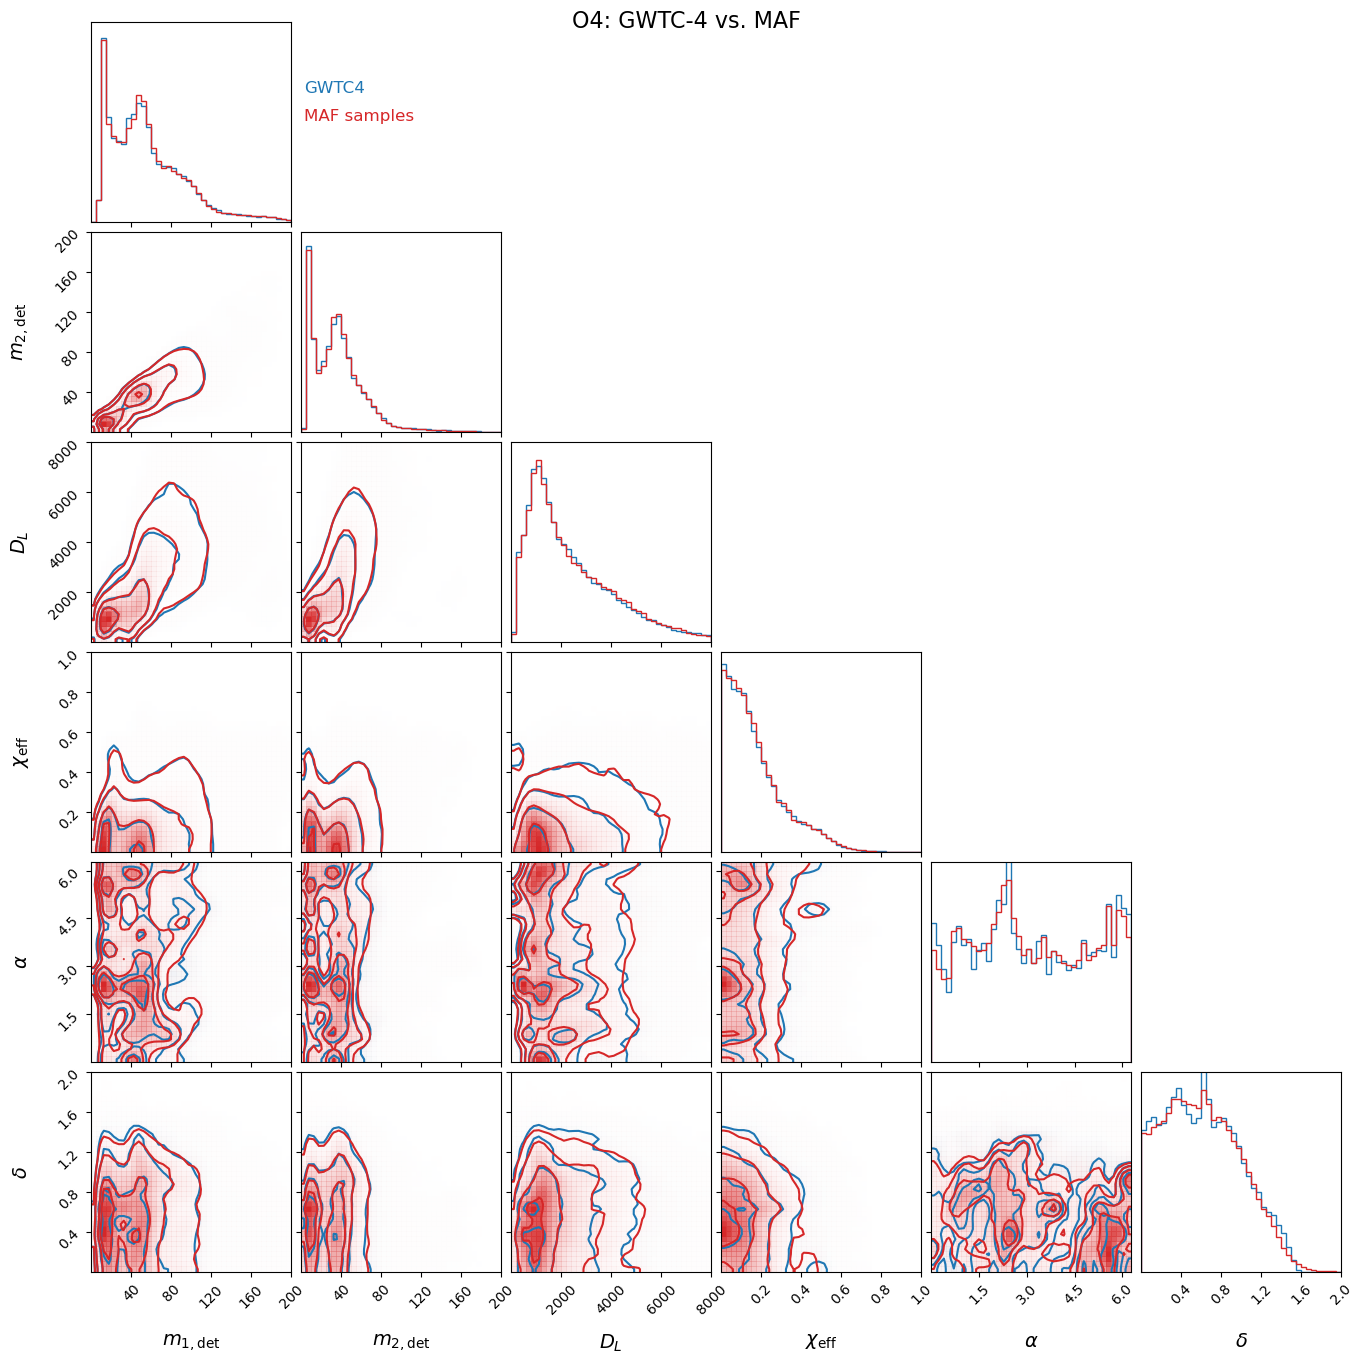

In [54]:
# ============================================================
# 5. SAMPLING FROM THE FLOW
# ============================================================

key, subkey = jax.random.split(key)
z_samples = np.array(flow.sample(subkey, (N,)))

# ============================================================
# 6. INVERSE TRANSFORM BACK TO PHYSICAL SPACE
# ============================================================

x_rec = data.inverse_whiten_data(z_samples)

# ============================================================
# 7. DIAGNOSTIC CORNER PLOT
# ============================================================

labels = [r"$m_{1,\rm det}$", r"$m_{2,\rm det}$", r"$D_L$", r"$\chi_\mathrm{eff}$", r"$\alpha$", r"$\delta$"]
ranges = [(0, 200), (0, 200), (0, 8000), (0, 1), (0, 2*np.pi), (0, 2)]
fig = corner.corner(
    np.array(data.samples)[:],
    labels=labels,
    color="C0",
    bins=40,
    plot_datapoints=False,
    smooth=1.0,
    label_kwargs={"fontsize": 14},
    range = ranges,
)

corner.corner(
    np.array(x_rec),
    fig=fig,
    color="C3",
    bins=40,
    plot_datapoints=False,
    smooth=1.0,
    range = ranges,
)

fig.text(
    0.225, 0.92,
    "GWTC4",
    color="C0",
    fontsize=12,
)

fig.text(
    0.225, 0.9,
    "MAF samples",
    color="C3",
    fontsize=12,
)

plt.suptitle("O4: GWTC-4 vs. MAF", fontsize=16)
plt.savefig("GWTC4_MAF_FAR1.png", dpi = 100)
plt.show()

### Quantitative Evaluation: Summary Statistics

Let's compare the descriptive statistics (mean, standard deviation, and correlations) of the original samples and the flow-generated samples. A good fit should show similar statistics between the two sets.

In [55]:
# Convert to pandas DataFrames for easy summary statistics
df_samples = pd.DataFrame(np.array(data.samples), columns=labels)
df_rec = pd.DataFrame(x_rec, columns=labels)

print("--- Original Samples Summary Statistics ---")
display(df_samples.describe())

print("\n--- Flow-Generated Samples Summary Statistics ---")
display(df_rec.describe())

print("\n--- Original Samples Correlation Matrix ---")
display(df_samples.corr())

print("\n--- Flow-Generated Samples Correlation Matrix ---")
display(df_rec.corr())

--- Original Samples Summary Statistics ---


,"$m_{1,\rm det}$","$m_{2,\rm det}$",$D_L$,$\chi_\mathrm{eff}$,$\alpha$,$\delta$
count,62400.000000,62400.000000,62400.000000,62400.000000,62400.000000,62400.000000
mean,56.573669,36.458130,2539.337402,0.064392,3.180130,0.005287
std,38.167011,24.971544,1979.034668,0.196185,1.839791,0.709065
min,7.381477,2.569034,69.578499,-0.880472,0.000014,-1.562118
25%,27.334512,15.741540,1092.018097,-0.048745,1.665617,-0.582740
50%,49.266972,33.996016,1956.035706,0.053627,3.054116,-0.016219
75%,77.020676,48.780795,3493.388245,0.172986,4.830777,0.595705
max,406.242401,181.145950,17832.511719,0.856010,6.283134,1.566734



--- Flow-Generated Samples Summary Statistics ---


,"$m_{1,\rm det}$","$m_{2,\rm det}$",$D_L$,$\chi_\mathrm{eff}$,$\alpha$,$\delta$
count,62400.000000,62400.000000,62400.000000,62400.000000,62400.000000,62400.000000
mean,56.701096,36.705704,2573.933350,0.067909,3.171206,-0.006869
std,37.882988,24.881899,1973.795776,0.193850,1.807236,0.710343
min,0.000004,0.000012,0.000000,-3.141593,0.000001,-3.141592
25%,27.838856,16.081675,1105.672577,-0.046922,1.694027,-0.592659
50%,49.713099,34.359318,1989.333679,0.057161,3.018453,-0.034331
75%,76.700821,48.868975,3586.575134,0.175227,4.773223,0.577662
max,290.587158,227.620361,27322.074219,0.955782,6.283185,2.547712



--- Original Samples Correlation Matrix ---


,"$m_{1,\rm det}$","$m_{2,\rm det}$",$D_L$,$\chi_\mathrm{eff}$,$\alpha$,$\delta$
"$m_{1,\rm det}$",1.000000,0.822208,0.643753,0.154852,0.002679,-0.069377
"$m_{2,\rm det}$",0.822208,1.000000,0.643436,0.115642,-0.015317,-0.076680
$D_L$,0.643753,0.643436,1.000000,0.155622,-0.013501,-0.051219
$\chi_\mathrm{eff}$,0.154852,0.115642,0.155622,1.000000,0.078819,0.021739
$\alpha$,0.002679,-0.015317,-0.013501,0.078819,1.000000,0.005614
$\delta$,-0.069377,-0.076680,-0.051219,0.021739,0.005614,1.000000



--- Flow-Generated Samples Correlation Matrix ---


,"$m_{1,\rm det}$","$m_{2,\rm det}$",$D_L$,$\chi_\mathrm{eff}$,$\alpha$,$\delta$
"$m_{1,\rm det}$",1.000000,0.835429,0.652938,0.179244,0.023688,-0.069218
"$m_{2,\rm det}$",0.835429,1.000000,0.651056,0.132507,-0.002191,-0.076066
$D_L$,0.652938,0.651056,1.000000,0.165165,0.010469,-0.065317
$\chi_\mathrm{eff}$,0.179244,0.132507,0.165165,1.000000,0.097789,0.020567
$\alpha$,0.023688,-0.002191,0.010469,0.097789,1.000000,-0.002835
$\delta$,-0.069218,-0.076066,-0.065317,0.020567,-0.002835,1.000000


### Quantitative Evaluation: Kolmogorov-Smirnov (KS) Test

The Kolmogorov-Smirnov test is a non-parametric test that compares the empirical cumulative distribution functions (ECDFs) of two samples. We'll perform it for each 1D marginal distribution to check if the original and flow-generated samples come from the same underlying distribution. A small p-value (e.g., < 0.05) would suggest that the distributions are statistically significantly different.

In [56]:
from scipy import stats

print("--- Kolmogorov-Smirnov Test for 1D Marginals ---")
print("H0: The two samples are drawn from the same continuous distribution.")
print("If p-value is small (e.g., < 0.05), we reject H0, meaning distributions are likely different.")

for i, label in enumerate(labels):
    stat, p_value = stats.kstest(np.array(data.samples[:, i]), x_rec[:, i])
    print(f"\nParameter: {label}")
    print(f"  KS Statistic: {stat:.4f}")
    print(f"  P-value: {p_value:.4f}")
    if p_value < 0.05:
        print("  -> Distributions are statistically significantly different (reject H0)")
    else:
        print("  -> Distributions are not statistically significantly different (fail to reject H0)")

--- Kolmogorov-Smirnov Test for 1D Marginals ---
H0: The two samples are drawn from the same continuous distribution.
If p-value is small (e.g., < 0.05), we reject H0, meaning distributions are likely different.

Parameter: $m_{1,\rm det}$
  KS Statistic: 0.0120
  P-value: 0.0003
  -> Distributions are statistically significantly different (reject H0)

Parameter: $m_{2,\rm det}$
  KS Statistic: 0.0134
  P-value: 0.0000
  -> Distributions are statistically significantly different (reject H0)

Parameter: $D_L$
  KS Statistic: 0.0142
  P-value: 0.0000
  -> Distributions are statistically significantly different (reject H0)

Parameter: $\chi_\mathrm{eff}$
  KS Statistic: 0.0099
  P-value: 0.0042
  -> Distributions are statistically significantly different (reject H0)

Parameter: $\alpha$
  KS Statistic: 0.0128
  P-value: 0.0001
  -> Distributions are statistically significantly different (reject H0)

Parameter: $\delta$
  KS Statistic: 0.0083
  P-value: 0.0265
  -> Distributions are statis